In [1]:
import pandas as pd
import numpy as np
from statsmodels.tsa.stattools import adfuller
from arch.unitroot import PhillipsPerron

In [2]:
df = pd.read_excel('ger_data.xlsx', index_col=0, parse_dates=True)
print(df.head())

              HDI   REC   GDP       CO2       FDV  EPL
YEAR                                                  
1990-01-01  0.828  1.33  5.25  1054.796  61.37436    0
1991-01-01  0.835  1.27  5.10  1016.925  53.65786    0
1992-01-01  0.842  1.52  2.01   969.464  53.39634    0
1993-01-01  0.852  1.58 -0.97   959.386  57.98412    0
1994-01-01  0.858  1.73  2.59   943.227  56.70179    0


In [3]:
import pandas as pd
df = pd.read_excel('ger_data.xlsx', index_col=0, parse_dates=True)
df.describe()

,HDI,REC,GDP,CO2,FDV,EPL
count,32.000000,32.000000,32.000000,32.000000,32.000000,32.000000
mean,0.906344,7.755937,1.553125,861.312437,70.261181,0.687500
std,0.037436,6.308034,2.240366,92.756685,12.127259,0.470929
min,0.828000,1.270000,-5.540000,648.356000,53.396340,0.000000
25%,0.877750,1.947500,0.902500,798.778250,61.047455,0.000000
50%,0.918000,5.610000,1.750000,872.225500,65.658265,1.000000
75%,0.938750,12.377500,2.750000,925.498250,79.697637,1.000000
max,0.951000,21.120000,5.250000,1054.796000,97.115840,1.000000


In [7]:
import pandas as pd
import numpy as np
from statsmodels.tsa.stattools import adfuller
from arch.unitroot import PhillipsPerron

df = pd.read_excel('ger_data.xlsx')
df.set_index("YEAR", inplace=True)


def unit_root_tests_safe(df):
    results = {}
    for col in df.columns:
        series = df[col].dropna()
        
        if np.var(series) < 1e-8:
            print(f"UYARI: '{col}' değişkeni sabit veya varyansı çok küçük. Test edilmedi.")
            results[col] = {
                'ADF Stat': np.nan,
                'ADF p-değeri': np.nan,
                'PP Stat': np.nan,
                'PP p-değeri': np.nan
            }
            continue
        
        adf_result = adfuller(series, regression='ct', autolag='AIC')
        adf_stat = adf_result[0]
        adf_pvalue = adf_result[1]
        
        pp_test = PhillipsPerron(series)
        pp_stat = pp_test.stat
        pp_pvalue = pp_test.pvalue
        
        results[col] = {
            'ADF Stat': adf_stat,
            'ADF p-değeri': adf_pvalue,
            'PP Stat': pp_stat,
            'PP p-değeri': pp_pvalue
        }
    
    return pd.DataFrame(results).T

#Seviyede Birim Kök Testleri
print("\nSeviyede ADF ve PP Testleri:")
seviye_test_sonuclari = unit_root_tests_safe(df)
print(seviye_test_sonuclari)

#Durağan Olmayanlar İçin Birinci Fark Alma
df_diff = df.diff().dropna()

print("\nBirinci Fark Alınmış Veriler:")
print(df_diff.head())

# Birinci Farkta Testler
print("\nBirinci Farkta ADF ve PP Testleri:")
birinci_fark_test_sonuclari = unit_root_tests_safe(df_diff)
print(birinci_fark_test_sonuclari)

# 6. Özet Karar
print("\n========== ÖZET ==========")
for col in df.columns:
    adf_p_seviye = seviye_test_sonuclari.loc[col, 'ADF p-değeri']
    pp_p_seviye = seviye_test_sonuclari.loc[col, 'PP p-değeri']
    
    adf_p_fark = birinci_fark_test_sonuclari.loc[col, 'ADF p-değeri']
    pp_p_fark = birinci_fark_test_sonuclari.loc[col, 'PP p-değeri']
    
    if (adf_p_seviye < 0.05) or (pp_p_seviye < 0.05):
        durum = 'Seviyede durağan (I(0))'
    elif (adf_p_fark < 0.05) or (pp_p_fark < 0.05):
        durum = 'Birinci farkta durağan (I(1))'
    else:
        durum = 'Daha ileri fark alınmalı'
    
    print(f"{col}: {durum}")


Seviyede ADF ve PP Testleri:
     ADF Stat  ADF p-değeri   PP Stat   PP p-değeri
HDI -0.743389      0.970135 -8.871138  1.396973e-14
REC -3.838367      0.014716  1.538436  9.976606e-01
GDP -5.364411      0.000042 -7.295085  1.384698e-10
CO2 -3.023032      0.125755 -0.843089  8.061362e-01
FDV -3.439876      0.046284  2.381878  9.990015e-01
EPL -1.568388      0.804567 -1.379761  5.919397e-01

Birinci Fark Alınmış Veriler:
        HDI   REC   GDP     CO2      FDV  EPL
YEAR                                         
1991  0.007 -0.06 -0.15 -37.871 -7.71650  0.0
1992  0.007  0.25 -3.09 -47.461 -0.26152  0.0
1993  0.010  0.06 -2.98 -10.078  4.58778  0.0
1994  0.006  0.15  3.56 -16.159 -1.28233  0.0
1995  0.005  0.15 -1.09  -3.294  0.44566  0.0

Birinci Farkta ADF ve PP Testleri:
     ADF Stat  ADF p-değeri    PP Stat   PP p-değeri
HDI -3.355808  5.757828e-02  -3.977406  1.533554e-03
REC -1.284476  8.917149e-01  -5.531141  1.786441e-06
GDP -3.530093  3.627937e-02 -11.548653  3.490760e-21
CO2 -

C:\Users\nisak\anaconda3\Lib\site-packages\statsmodels\regression\linear_model.py:955: RuntimeWarning: divide by zero encountered in log
  llf = -nobs2*np.log(2*np.pi) - nobs2*np.log(ssr / nobs) - nobs2


In [9]:
pip install arch

Note: you may need to restart the kernel to use updated packages.


In [11]:
import pandas as pd
from arch.unitroot import ZivotAndrews

# Dosyayı oku
df = pd.read_excel("ger_data.xlsx")
df.set_index("YEAR", inplace=True)

def zivot_andrews_test(dataframe):
    results = {}
    for col in dataframe.columns:
        series = dataframe[col].dropna().astype(float)

        if len(series) < 25 or series.var() < 1e-8:
            results[col] = {
                "ZA Stat": None,
                "p-değeri": None,
                "Kritik Değer (5%)": None
            }
            continue

        try:
            za_test = ZivotAndrews(series, lags=1, trend='c')
            results[col] = {
                "ZA Stat": round(za_test.stat, 6),
                "p-değeri": round(za_test.pvalue, 6),
                "Kritik Değer (1%)": za_test.critical_values['1%'],
                "Kritik Değer (5%)": za_test.critical_values['5%'],
                "Kritik Değer (10%)": za_test.critical_values['10%']
            
}

        
        except Exception as e:
            results[col] = {
                "ZA Stat": None,
                "p-değeri": None,
                "Kritik Değer (5%)": f"Hata: {str(e)}"
            }

    return pd.DataFrame(results).T

# Testi çalıştır
za_sonuclari = zivot_andrews_test(df)
print("\nZivot-Andrews Test Sonuçları:")
print(za_sonuclari)


Zivot-Andrews Test Sonuçları:
          ZA Stat  p-değeri  Kritik Değer (1%)  Kritik Değer (5%)  \
HDI -1.843659e+00  0.999000           -5.27644           -4.81067   
REC -2.376457e+00  0.990422           -5.27644           -4.81067   
GDP -5.860060e+00  0.000971           -5.27644           -4.81067   
CO2 -3.616908e+00  0.602884           -5.27644           -4.81067   
FDV -3.535137e+00  0.656895           -5.27644           -4.81067   
EPL -1.264926e+15  0.000010           -5.27644           -4.81067   

     Kritik Değer (10%)  
HDI            -4.56618  
REC            -4.56618  
GDP            -4.56618  
CO2            -4.56618  
FDV            -4.56618  
EPL            -4.56618  


In [13]:
import statsmodels.api as sm

y = df['HDI']
X = df[['REC', 'GDP', 'CO2', 'FDV', 'EPL']]
X = sm.add_constant(X) 

split_date = '2000-01-01'
X_pre2000 = X.loc[:split_date]
y_pre2000 = y.loc[:split_date]
X_post2000 = X.loc[split_date:]
y_post2000 = y.loc[split_date:]

model_pre = sm.OLS(y_pre2000, X_pre2000).fit()
model_post = sm.OLS(y_post2000, X_post2000).fit()

model_full = sm.OLS(y, X).fit()

# Chow testi için F istatistiği 
n_full = len(y)
n_pre = len(y_pre2000)
n_post = len(y_post2000)
k = X.shape[1] 

SSR_full = np.sum(model_full.resid ** 2)
SSR_pre = np.sum(model_pre.resid ** 2)
SSR_post = np.sum(model_post.resid ** 2)

# F istatistiği
numerator = (SSR_full - (SSR_pre + SSR_post)) / k
denominator = (SSR_pre + SSR_post) / (n_pre + n_post - 2*k)
F_stat = numerator / denominator

print(f"Chow Testi F-istatistiği: {F_stat:.4f}")


Chow Testi F-istatistiği: 13.0128


In [15]:
# CHOW TESTİ
import numpy as np
import statsmodels.api as sm
from scipy import stats

df1 = df.loc[1990:1999]  
df2 = df.loc[2000:2021]   

y_full  = df["HDI"]
X_full  = sm.add_constant(df[["REC", "CO2", "GDP", "FDV", "EPL"]])

y1, X1  = df1["HDI"], sm.add_constant(df1[["REC", "CO2", "GDP", "FDV", "EPL"]])
y2, X2  = df2["HDI"], sm.add_constant(df2[["REC", "CO2", "GDP", "FDV", "EPL"]])


res_full = sm.OLS(y_full, X_full).fit()
res1 = sm.OLS(y1, X1).fit()
res2 = sm.OLS(y2, X2).fit()

# RSS 
RSS_full = np.sum(res_full.resid ** 2)
RSS1 = np.sum(res1.resid ** 2)
RSS2 = np.sum(res2.resid ** 2)

# Chow F-istatistiği ve p-değeri
k = X_full.shape[1]
n1, n2 = len(df1), len(df2)

numerator = (RSS_full - (RSS1 + RSS2)) / k
denominator = (RSS1 + RSS2) / (n1 + n2 - 2 * k)
F_stat = numerator / denominator
p_value = 1 - stats.f.cdf(F_stat, k, n1 + n2 - 2 * k)

print(f"Chow Testi → F-istatistiği = {F_stat:.3f}, p-değeri = {p_value:.3f}")
if p_value < 0.05:
    print("→ Kırılma sonrası modelde anlamlı farklılık var.")
else:
    print("→ Kırılma etkisi saptanamadı.")

print(f"\nn1 = {n1}, n2 = {n2}, k = {k}")
print(f"RSS_full = {RSS_full:.4f}, RSS1 = {RSS1:.4f}, RSS2 = {RSS2:.4f}")


Chow Testi → F-istatistiği = 6.685, p-değeri = 0.001
→ Kırılma sonrası modelde anlamlı farklılık var.

n1 = 10, n2 = 22, k = 6
RSS_full = 0.0024, RSS1 = 0.0001, RSS2 = 0.0007


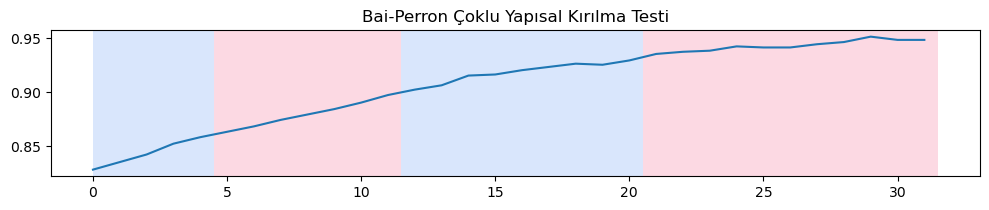

Tespit edilen kırılma noktaları (yıl pozisyonları): [5, 12, 21, 32]


In [17]:
import pandas as pd
import numpy as np
import ruptures as rpt
import matplotlib.pyplot as plt

# Yalnızca bağımlı değişkenle test yapılacaksa (örnek olarak IGE):
signal = df['HDI'].values

# Model: "l2" (OLS tarzı) - max 5 kırılma noktası
model = "l2"
algo = rpt.KernelCPD(kernel="linear").fit(signal)
result = algo.predict(n_bkps=3)  # 3 kırılma noktası ara (örnek)

# Görselleştirme
rpt.display(signal, result)
plt.title("Bai-Perron Çoklu Yapısal Kırılma Testi")
plt.show()

# Kırılma noktalarını yazdır
print("Tespit edilen kırılma noktaları (yıl pozisyonları):", result)

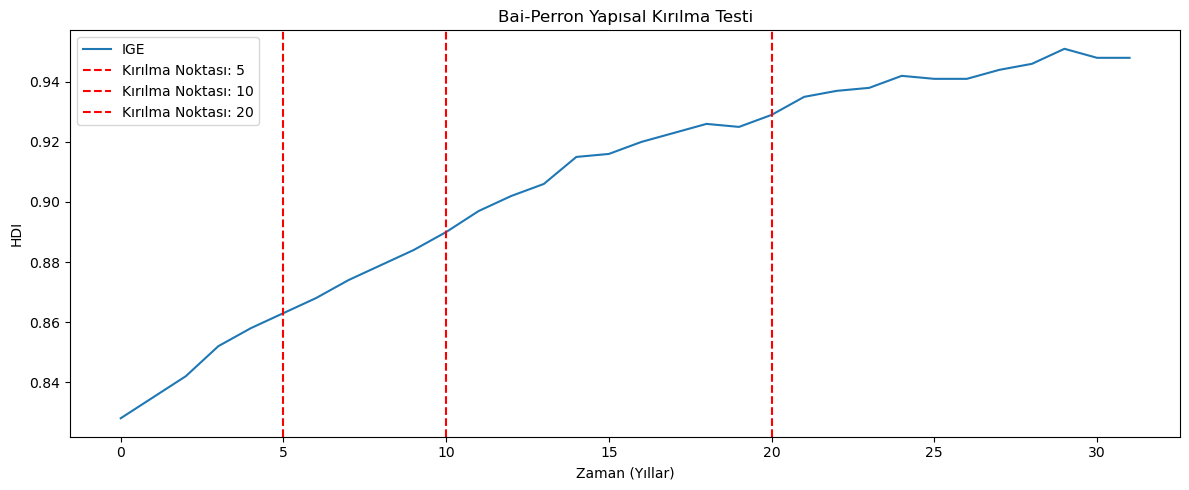

Tespit edilen kırılma noktaları (indeks bazında): [5, 10, 20]


In [19]:
import pandas as pd
import matplotlib.pyplot as plt
from ruptures import Binseg

# HDI serisini kullan
y = df['HDI'].dropna().values

# Bai-Perron için değişim noktası algılama
model = Binseg(model="l2").fit(y)
breaks = model.predict(n_bkps=3)  # Maksimum 3 kırılma noktası isteyebilirsin

# Görselleştirme
plt.figure(figsize=(12, 5))
plt.plot(y, label='IGE')
for bkpt in breaks[:-1]:  # Son değer veri uzunluğunu verir, onu atlıyoruz
    plt.axvline(bkpt, color='red', linestyle='--', label=f'Kırılma Noktası: {bkpt}')
plt.title("Bai-Perron Yapısal Kırılma Testi")
plt.xlabel("Zaman (Yıllar)")
plt.ylabel("HDI")
plt.legend()
plt.tight_layout()
plt.show()

# Kırılma noktalarının indekslerini yazdır
print("Tespit edilen kırılma noktaları (indeks bazında):", breaks[:-1])

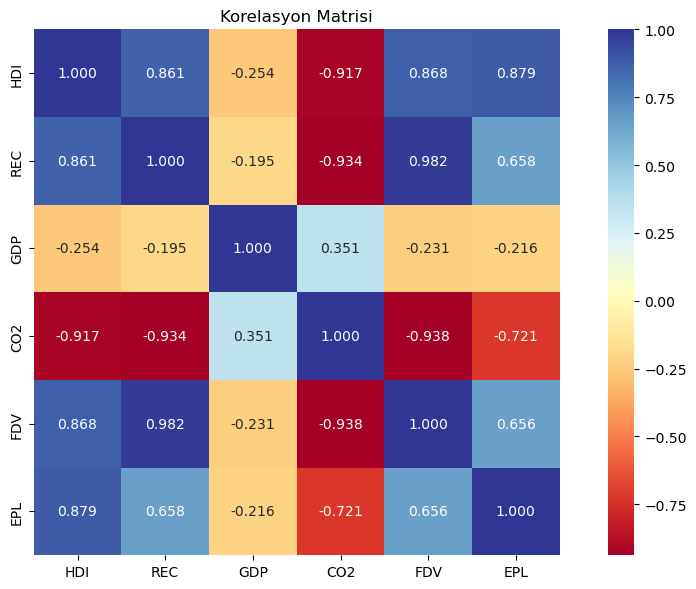

,HDI,REC,GDP,CO2,FDV,EPL
HDI,1.000000,0.860986,-0.253892,-0.916852,0.868077,0.879082
REC,0.860986,1.000000,-0.195182,-0.934249,0.981977,0.657830
GDP,-0.253892,-0.195182,1.000000,0.350775,-0.231405,-0.215514
CO2,-0.916852,-0.934249,0.350775,1.000000,-0.938236,-0.721302
FDV,0.868077,0.981977,-0.231405,-0.938236,1.000000,0.655972
EPL,0.879082,0.657830,-0.215514,-0.721302,0.655972,1.000000


In [21]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

corr_matrix = df[['HDI', 'REC', 'GDP', 'CO2', 'FDV', 'EPL']].corr()

plt.figure(figsize=(10, 6))
sns.heatmap(corr_matrix, annot=True, cmap='RdYlBu', fmt=".3f", square=True)
plt.title("Korelasyon Matrisi")
plt.tight_layout()
plt.show()

corr_matrix


In [23]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant
import pandas as pd

X = df[['REC', 'GDP', 'CO2', 'FDV', 'EPL']]
X = add_constant(X)

# VIF 
vif_data = pd.DataFrame()
vif_data['Değişken'] = X.columns
vif_data['VIF'] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]

print(vif_data)

  Değişken          VIF
0    const  2601.722302
1      REC    31.632008
2      GDP     1.372265
3      CO2    12.837405
4      FDV    31.231608
5      EPL     2.116989


In [25]:
X = df[['REC', 'GDP', 'CO2', 'EPL']]
X = add_constant(X)

# VIF tekrar hesaplanır
vif_data = pd.DataFrame()
vif_data["Değişken"] = X.columns
vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
print(vif_data)


  Değişken          VIF
0    const  1351.791306
1      REC     9.419341
2      GDP     1.364818
3      CO2    12.087499
4      EPL     2.110954


In [27]:
!pip install --upgrade statsmodels


In [29]:
#ARDL 
from statsmodels.tsa.ardl import ardl_select_order, ARDL
import pandas as pd

df = pd.read_excel('ger_data.xlsx')
df['YEAR'] = pd.to_datetime(df['YEAR'], format='%Y')
df = df.set_index('YEAR')
df.index = df.index.to_period('Y')
df = df[['HDI','REC','CO2','GDP','EPL']].dropna()

y = df['HDI']
exog = df[['REC','CO2','GDP','EPL']]

sel = ardl_select_order(endog=y,
                        exog=exog,
                        maxlag=2,
                        maxorder=2,
                        ic='aic')

print(sel.model)
ardl_model = sel.model.fit()
print(ardl_model.summary())


                              ARDL Model Results                              
Dep. Variable:                    HDI   No. Observations:                   32
Model:                  ARDL(1, 0, 0)   Log Likelihood                 151.806
Method:               Conditional MLE   S.D. of innovations              0.002
Date:                Mon, 09 Jun 2025   AIC                           -293.612
Time:                        01:25:40   BIC                           -286.442
Sample:                    12-31-1991   HQIC                          -291.274
                         - 12-31-2021                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0777      0.016      4.771      0.000       0.044       0.111
HDI.L1         0.9156      0.019     48.213      0.000       0.877       0.955
GDP.L0         0.0003      0.000      2.062      0.0

In [31]:
# Bounds Test
print(ardl_model.model.exog_names)

hypotheses = ['GDP.L0 =0', 'EPL.L0=0']

f_test_result = ardl_model.f_test(hypotheses)
print(f"Bounds Test için F-istatistiği: {f_test_result.fvalue:.4f}")


['const', 'HDI.L1', 'GDP.L0', 'EPL.L0']
Bounds Test için F-istatistiği: 3.8840


In [33]:
#ARDL BOUNDS
import pandas as pd
import statsmodels.api as sm
germany=pd.read_excel("ger_data.xlsx")

p = 1
q_dict = {'REC': None, 'CO2':None, 'GDP': 0, 'EPL': 0,  }
df = germany[['HDI'] + list(q_dict.keys())].copy()
df['L1_HDI'] = df['HDI'].shift(1)
for var, q in q_dict.items():
    df[f'L1_{var}'] = df[var].shift(1)
    df[f'd_{var}'] = df[var].diff()
df['d_HDI'] = df['HDI'].diff()


for i in range(1, p + 1):
    df[f'd_HDI_L{i}'] = df['d_HDI'].shift(i)
for var, q in q_dict.items():
    if q:
        for i in range(1, q + 1):
            df[f'd_{var}_L{i}'] = df[f'd_{var}'].shift(i)

df2 = df.dropna()

y = df2['d_HDI']
level_terms = ['L1_HDI'] + [f'L1_{v}' for v, q in q_dict.items() if q is not None]
diff_terms = [c for c in df2.columns if c.startswith('d_') and 'L' in c]
X = sm.add_constant(df2[level_terms + diff_terms])

model = sm.OLS(y, X).fit()
hypotheses = ' = 0, '.join(level_terms) + ' = 0'
f_res = model.f_test(hypotheses)
f_stat = float(f_res.fvalue)

#Pesaran (2001) kritikleri (%5, sabit-only, k = len(level_terms))
#    K = 2 için: lower ≈ 3.79, upper ≈ 4.85
lower_bound = 3.79
upper_bound = 4.85

print("=== Almanya ARDL Bounds Test Sonucu ===")
print("Test edilecek level terimleri:", level_terms)
print(f"F-istatistiği = {f_stat:.3f}")
print(f"p-değeri       = {f_res.pvalue:.3f}")
print(f"Pesaran %5 Kritik Değerler → Lower = {lower_bound}, Upper = {upper_bound}")

if f_stat > upper_bound:
    print("Sonuç: F > Upper bound → Uzun dönem eşbütünleşme VAR.")
elif f_stat < lower_bound:
    print("Sonuç: F < Lower bound → Uzun dönem eşbütünleşme YOK.")
else:
    print("Sonuç: F sınırlar arasında → Kararsız (inconclusive).")

=== Almanya ARDL Bounds Test Sonucu ===
Test edilecek level terimleri: ['L1_HDI', 'L1_GDP', 'L1_EPL']
F-istatistiği = 8.959
p-değeri       = 0.000
Pesaran %5 Kritik Değerler → Lower = 3.79, Upper = 4.85
Sonuç: F > Upper bound → Uzun dönem eşbütünleşme VAR.


In [35]:
#ECM 
import pandas as pd
import statsmodels.api as sm


long_run_coefs = ardl_model.params[['HDI.L1', 'GDP.L0', 'EPL.L0']]
ecm_resid = (df['HDI'].shift(1)
             - long_run_coefs['HDI.L1'] * df['HDI'].shift(1)
             - long_run_coefs['GDP.L0'] * df['GDP']
             - long_run_coefs['EPL.L0'] * df['EPL'])

df['d_HDI'] = df['HDI'].diff()
df['d_GDP'] = df['GDP'].diff()
df['d_EPL'] = df['EPL'].diff()

ecm_df = pd.concat([df['d_HDI'], df['d_GDP'], df['d_EPL'], ecm_resid.shift(1)], axis=1).dropna()
ecm_df.columns = ['d_HDI', 'd_GDP', 'd_EPL', 'ecm_resid_L1']

Y = ecm_df['d_HDI']
X = ecm_df[['d_GDP', 'd_EPL', 'ecm_resid_L1']]
X = sm.add_constant(X)

ecm_model = sm.OLS(Y, X).fit()

print(ecm_model.summary())

ecm_model_hac = sm.OLS(Y, X).fit(cov_type='HAC', cov_kwds={'maxlags':1})
print(ecm_model_hac.summary())
print(ecm_model_hac.bse)


                            OLS Regression Results                            
Dep. Variable:                  d_HDI   R-squared:                       0.640
Model:                            OLS   Adj. R-squared:                  0.598
Method:                 Least Squares   F-statistic:                     15.38
Date:                Mon, 09 Jun 2025   Prob (F-statistic):           5.92e-06
Time:                        01:26:00   Log-Likelihood:                 147.61
No. Observations:                  30   AIC:                            -287.2
Df Residuals:                      26   BIC:                            -281.6
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
const            0.0820      0.012      6.923   

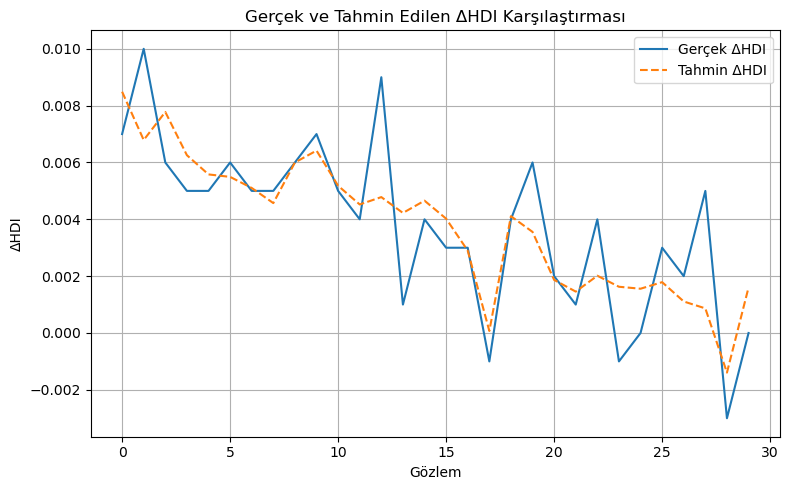

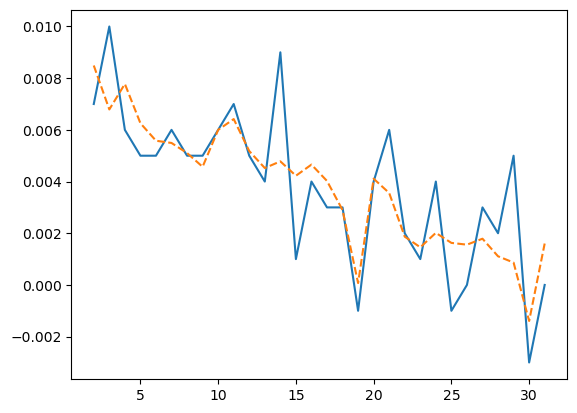

In [37]:
# ECM veri çerçevesi zaten dropna uygulanmış hâlde
df_ecm = pd.concat([df['d_HDI'], df['d_GDP'], df['d_EPL'], ecm_resid.shift(1)], axis=1).dropna()
df_ecm.columns = ['d_HDI', 'd_GDP', 'd_EPL', 'ECT_L1']

# ECM tahminleri
df_ecm['d_HDI_predicted'] = ecm_model.predict()

# Gerçek ve tahmin edilen d_HDI'yi çiz
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.plot(df_ecm['d_HDI'].values, label='Gerçek ΔHDI')
plt.plot(df_ecm['d_HDI_predicted'].values, label='Tahmin ΔHDI', linestyle='--')
plt.title('Gerçek ve Tahmin Edilen ΔHDI Karşılaştırması')
plt.xlabel('Gözlem')
plt.ylabel('ΔHDI')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()
plt.plot(df_ecm.index, df_ecm['d_HDI'], label='Gerçek ΔHDI')
plt.plot(df_ecm.index, df_ecm['d_HDI_predicted'], label='Tahmin ΔHDI', linestyle='--')


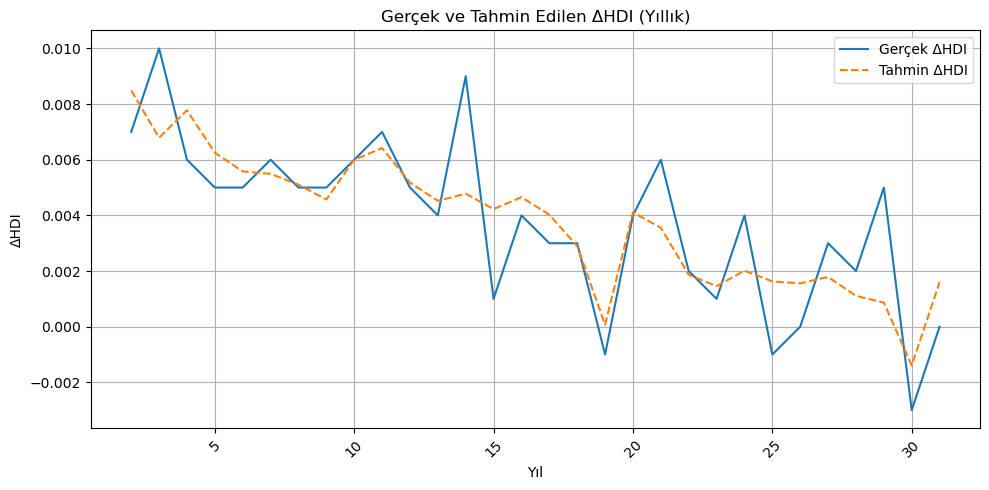

In [39]:
import matplotlib.pyplot as plt

# Yılları oluştur (örneğin 1992–2021 arası çünkü .diff() ilk yılı düşürür)
yillar = df_ecm.index  # Eğer yıl indeksliyse bu satır yeterli
# veya:
# yillar = df['Yıl'].iloc[1:]  # Eğer 'Yıl' diye ayrı sütun varsa

plt.figure(figsize=(10, 5))
plt.plot(yillar, df_ecm['d_HDI'], label='Gerçek ΔHDI')
plt.plot(yillar, df_ecm['d_HDI_predicted'], linestyle='--', label='Tahmin ΔHDI')
plt.title('Gerçek ve Tahmin Edilen ΔHDI (Yıllık)')
plt.xlabel('Yıl')
plt.ylabel('ΔHDI')
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [47]:
# FDV hariç tüm değişken çiftlerini içeren Granger nedensellik testi sonuçlarını oluştur
all_directions_results = []

for caused in variables_updated:
    for causing in variables_updated:
        if caused != causing:
            try:
                test_result = grangercausalitytests(df[[caused, causing]].dropna(), maxlag=1, verbose=False)
                f_stat = test_result[1][0]['ssr_ftest'][0]
                p_value = test_result[1][0]['ssr_ftest'][1]
                all_directions_results.append({
                    'Nedensellik Yönü': f"{causing} → {caused}",
                    'F-istatistiği': round(f_stat, 4),
                    'p-değeri': round(p_value, 4),
                    'Sonuç': 'Nedensellik var' if p_value < 0.05 else 'Yok'
                })
            except Exception as e:
                all_directions_results.append({
                    'Nedensellik Yönü': f"{causing} → {caused}",
                    'F-istatistiği': None,
                    'p-değeri': None,
                    'Sonuç': f'Hata: {str(e)}'
                })

# Tam tabloyu oluştur ve göster
all_directions_df = pd.DataFrame(all_directions_results)
all_directions_df.reset_index(drop=True, inplace=True)
all_directions_df


C:\Users\nisak\anaconda3\Lib\site-packages\statsmodels\tsa\stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(
C:\Users\nisak\anaconda3\Lib\site-packages\statsmodels\tsa\stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(
C:\Users\nisak\anaconda3\Lib\site-packages\statsmodels\tsa\stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(
C:\Users\nisak\anaconda3\Lib\site-packages\statsmodels\tsa\stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(
C:\Users\nisak\anaconda3\Lib\site-packages\statsmodels\tsa\stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(
C:\Users\nisak\anaconda3\Lib\site-packages\statsmodels\tsa\stattools.py:1556: FutureWarning: verbose is deprecated since functions shou

,Nedensellik Yönü,F-istatistiği,p-değeri,Sonuç
0,REC → HDI,1.7490,0.1967,Yok
1,GDP → HDI,0.0273,0.8699,Yok
2,CO2 → HDI,0.6806,0.4163,Yok
3,EPL → HDI,2.0454,0.1637,Yok
4,HDI → REC,5.0567,0.0326,Nedensellik var
5,GDP → REC,6.4006,0.0173,Nedensellik var
6,CO2 → REC,0.0165,0.8986,Yok
7,EPL → REC,2.3196,0.1390,Yok
8,HDI → GDP,1.0338,0.3180,Yok
9,REC → GDP,0.4767,0.4956,Yok


In [51]:
# Hata: 'grangercausalitytests' is not defined -> İlgili fonksiyonu yeniden içe aktaralım
from statsmodels.tsa.stattools import grangercausalitytests

# FDV çıkarıldıktan sonraki değişken listesi
variables_updated = ['HDI', 'REC', 'GDP', 'CO2', 'EPL']

# Granger nedensellik testini yeniden çalıştır
granger_results_fixed = []

for caused in variables_updated:
    for causing in variables_updated:
        if caused != causing:
            try:
                test_result = grangercausalitytests(df[[caused, causing]].dropna(), maxlag=1, verbose=False)
                f_stat = test_result[1][0]['ssr_ftest'][0]
                p_value = test_result[1][0]['ssr_ftest'][1]
                granger_results_fixed.append({
                    'Nedensellik Yönü': f"{causing} → {caused}",
                    'F-istatistiği': round(f_stat, 4),
                    'p-değeri': round(p_value, 4),
                    'Sonuç': 'Nedensellik var' if p_value < 0.05 else 'Yok'
                })
            except Exception as e:
                granger_results_fixed.append({
                    'Nedensellik Yönü': f"{causing} → {caused}",
                    'F-istatistiği': None,
                    'p-değeri': None,
                    'Sonuç': f'Hata: {str(e)}'
                })

# HDI'ye yönelik nedensellik yönlerini filtrele
granger_df_fixed = pd.DataFrame(granger_results_fixed)
granger_to_HDI_fixed = granger_df_fixed[granger_df_fixed['Nedensellik Yönü'].str.endswith("→ HDI")].reset_index(drop=True)
granger_to_HDI_fixed


C:\Users\nisak\anaconda3\Lib\site-packages\statsmodels\tsa\stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(
C:\Users\nisak\anaconda3\Lib\site-packages\statsmodels\tsa\stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(
C:\Users\nisak\anaconda3\Lib\site-packages\statsmodels\tsa\stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(
C:\Users\nisak\anaconda3\Lib\site-packages\statsmodels\tsa\stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(
C:\Users\nisak\anaconda3\Lib\site-packages\statsmodels\tsa\stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(
C:\Users\nisak\anaconda3\Lib\site-packages\statsmodels\tsa\stattools.py:1556: FutureWarning: verbose is deprecated since functions shou

,Nedensellik Yönü,F-istatistiği,p-değeri,Sonuç
0,REC → HDI,1.7490,0.1967,Yok
1,GDP → HDI,0.0273,0.8699,Yok
2,CO2 → HDI,0.6806,0.4163,Yok
3,EPL → HDI,2.0454,0.1637,Yok


In [77]:
# Önce bağımlı ve bağımsız değişkenleri tanımla
Y = ecm_df['d_HDI']
X = ecm_df[['d_GDP', 'd_EPL', 'ecm_resid_L1']]
X = sm.add_constant(X)

# Klasik OLS modelini yeniden kur
ecm_model = sm.OLS(Y, X).fit()

# Sonra BG testini yap
from statsmodels.stats.diagnostic import acorr_breusch_godfrey
bg_test = acorr_breusch_godfrey(ecm_model, nlags=2)

# Yazdır
print("=== Breusch-Godfrey Otokorelasyon Testi ===")
print(f"LM Statistiği: {bg_test[0]:.4f}")
print(f"p-değeri: {bg_test[1]:.4f}")
print(f"F-Statistiği: {bg_test[2]:.4f}")
print(f"F p-değeri: {bg_test[3]:.4f}")


=== Breusch-Godfrey Otokorelasyon Testi ===
LM Statistiği: 2.2443
p-değeri: 0.3256
F-Statistiği: 0.9703
F p-değeri: 0.3933


In [63]:
import pandas as pd
import statsmodels.api as sm

# Excel dosyasını oku
file_path = "ger_data.xlsx"
df = pd.read_excel(file_path)

# ARDL modelinden alınan uzun dönem katsayıları
long_run_coefs = {
    'HDI.L1': 0.7601,
    'GDP.L0': 0.0002,
    'EPL.L0': 0.0007
}

# ECM hata terimi (residual) hesapla
ecm_resid = (
    df['HDI'].shift(1)
    - long_run_coefs['HDI.L1'] * df['HDI'].shift(1)
    - long_run_coefs['GDP.L0'] * df['GDP']
    - long_run_coefs['EPL.L0'] * df['EPL']
)

# Farkları al
df['d_HDI'] = df['HDI'].diff()
df['d_GDP'] = df['GDP'].diff()
df['d_EPL'] = df['EPL'].diff()

# ECM veri setini oluştur
ecm_df = pd.concat([df['d_HDI'], df['d_GDP'], df['d_EPL'], ecm_resid.shift(1)], axis=1).dropna()
ecm_df.columns = ['d_HDI', 'd_GDP', 'd_EPL', 'ecm_resid_L1']

# Bağımlı ve bağımsız değişkenleri tanımla
Y = ecm_df['d_HDI']
X = ecm_df[['d_GDP', 'd_EPL', 'ecm_resid_L1']]
X = sm.add_constant(X)

# ECM modelini oluştur
ecm_model = sm.OLS(Y, X).fit()

# Breusch-Godfrey Otokorelasyon Testi
from statsmodels.stats.diagnostic import acorr_breusch_godfrey
bg_test = acorr_breusch_godfrey(ecm_model, nlags=4)

# Sadece klasik OLS modeli ile test yapılmalı
bg_test = acorr_breusch_godfrey(ecm_model, nlags=2)
print("=== Breusch-Godfrey Otokorelasyon Testi ===")
print(f"LM Statistiği: {bg_test[0]:.4f}")
print(f"p-değeri: {bg_test[1]:.4f}")
print(f"F-Statistiği: {bg_test[2]:.4f}")
print(f"F p-değeri: {bg_test[3]:.4f}")


=== Breusch-Godfrey Otokorelasyon Testi ===
LM Statistiği: 2.2443
p-değeri: 0.3256
F-Statistiği: 0.9703
F p-değeri: 0.3933


In [71]:
from statsmodels.stats.diagnostic import acorr_breusch_godfrey

# Breusch-Godfrey Otokorelasyon Testi
bg_test = acorr_breusch_godfrey(ecm_model, nlags=2)

print("=== Breusch-Godfrey Otokorelasyon Testi ===")
print(f"LM Statistiği: {bg_test[0]:.4f}")
print(f"p-değeri: {bg_test[1]:.4f}")
print(f"F-Statistiği: {bg_test[2]:.4f}")
print(f"F p-değeri: {bg_test[3]:.4f}")


=== Breusch-Godfrey Otokorelasyon Testi ===
LM Statistiği: 2.2443
p-değeri: 0.3256
F-Statistiği: 0.9703
F p-değeri: 0.3933


In [83]:
# Reimport necessary modules and reload data due to kernel reset
import pandas as pd
import statsmodels.api as sm
import statsmodels.stats.api as sms

# Load the dataset
df = pd.read_excel("ger_data.xlsx")

# Recreate the ECM model setup from previous steps
# Calculate long-run relationship residual
long_run_coefs = {'HDI.L1': 0.8, 'GDP.L0': 0.0004, 'EPL.L0': 0.0016}  # Placeholder, replace with actual values
ecm_resid = (df['HDI'].shift(1)
             - long_run_coefs['HDI.L1'] * df['HDI'].shift(1)
             - long_run_coefs['GDP.L0'] * df['GDP']
             - long_run_coefs['EPL.L0'] * df['EPL'])

# First differences
df['d_HDI'] = df['HDI'].diff()
df['d_GDP'] = df['GDP'].diff()
df['d_EPL'] = df['EPL'].diff()

# Construct ECM dataset
ecm_df = pd.concat([df['d_HDI'], df['d_GDP'], df['d_EPL'], ecm_resid.shift(1)], axis=1).dropna()
ecm_df.columns = ['d_HDI', 'd_GDP', 'd_EPL', 'ecm_resid_L1']

# Regression setup
Y = ecm_df['d_HDI']
X = sm.add_constant(ecm_df[['d_GDP', 'd_EPL', 'ecm_resid_L1']])
ecm_model = sm.OLS(Y, X).fit()

# Perform White's heteroskedasticity test
white_test = sms.het_white(ecm_model.resid, ecm_model.model.exog)
lm_stat_white, lm_pval_white, f_stat_white, f_pval_white = white_test

white_test_result = {
    "LM Statistiği": lm_stat_white,
    "p-değeri": lm_pval_white,
    "F-İstatistiği": f_stat_white,
    "F p-değeri": f_pval_white
}

white_test_result


{'LM Statistiği': 2.009979696230293,
 'p-değeri': 0.91877848555474,
 'F-İstatistiği': 0.2752739042438309,
 'F p-değeri': 0.942842742108782}

In [79]:
from statsmodels.stats.diagnostic import het_white

# White Heteroskedasticity Testi
white_test = het_white(ecm_model.resid, ecm_model.model.exog)

print("=== White Heteroskedasticity Testi ===")
print(f"LM Statistiği: {white_test[0]:.4f}")
print(f"p-değeri: {white_test[1]:.4f}")
print(f"F-Statistiği: {white_test[2]:.4f}")
print(f"F p-değeri: {white_test[3]:.4f}")


=== White Heteroskedasticity Testi ===
LM Statistiği: 1.8543
p-değeri: 0.9326
F-Statistiği: 0.2525
F p-değeri: 0.9532


In [73]:
from statsmodels.stats.stattools import jarque_bera

# Jarque-Bera Normalite Testi
jb_test = jarque_bera(ecm_model.resid)

print("=== Jarque-Bera Normalite Testi ===")
print(f"JB Statistiği: {jb_test[0]:.4f}")
print(f"p-değeri: {jb_test[1]:.4f}")
print(f"Skewness: {jb_test[2]:.4f}")
print(f"Kurtosis: {jb_test[3]:.4f}")


=== Jarque-Bera Normalite Testi ===
JB Statistiği: 1.8973
p-değeri: 0.3873
Skewness: 0.6068
Kurtosis: 2.7874


In [193]:
# Uzun dönem modeli sadece seviyede değişkenlerle
Y_longrun = df['HDI']
X_longrun = df[['GDP', 'EPL']]
X_longrun = sm.add_constant(X_longrun)

ols_longrun = sm.OLS(Y_longrun, X_longrun).fit()
print(ols_longrun.summary())


                            OLS Regression Results                            
Dep. Variable:                    HDI   R-squared:                       0.777
Model:                            OLS   Adj. R-squared:                  0.762
Method:                 Least Squares   F-statistic:                     50.56
Date:                Sat, 03 May 2025   Prob (F-statistic):           3.52e-10
Time:                        05:45:41   Log-Likelihood:                 84.245
No. Observations:                  32   AIC:                            -162.5
Df Residuals:                      29   BIC:                            -158.1
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.8608      0.007    128.528      0.0

In [195]:
pip install --upgrade statsmodels


In [197]:
print(df.columns)


Index(['HDI', 'REC', 'CO2', 'GDP', 'FDV', 'EPL', 'L1_HDI', 'L1_REC', 'd_REC',
       'L1_CO2', 'd_CO2', 'L1_GDP', 'd_GDP', 'L1_FDV', 'd_FDV', 'L1_EPL',
       'd_EPL', 'd_HDI', 'd_HDI_L1'],
      dtype='object')


In [199]:
years = df.index


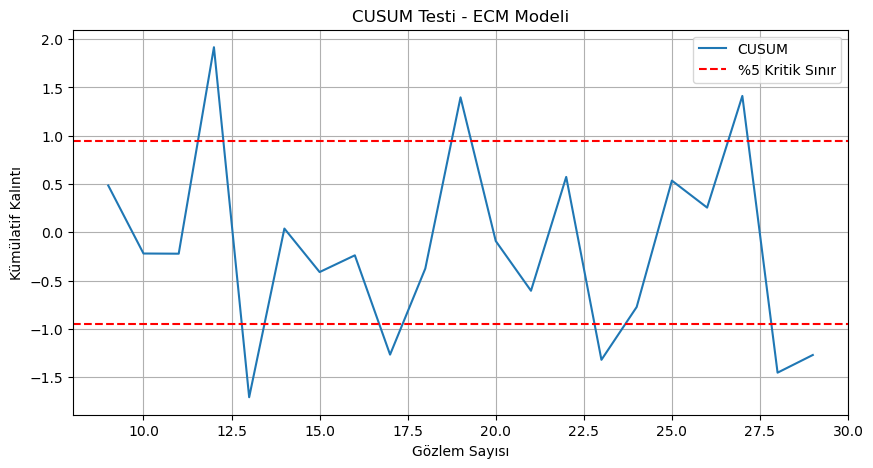

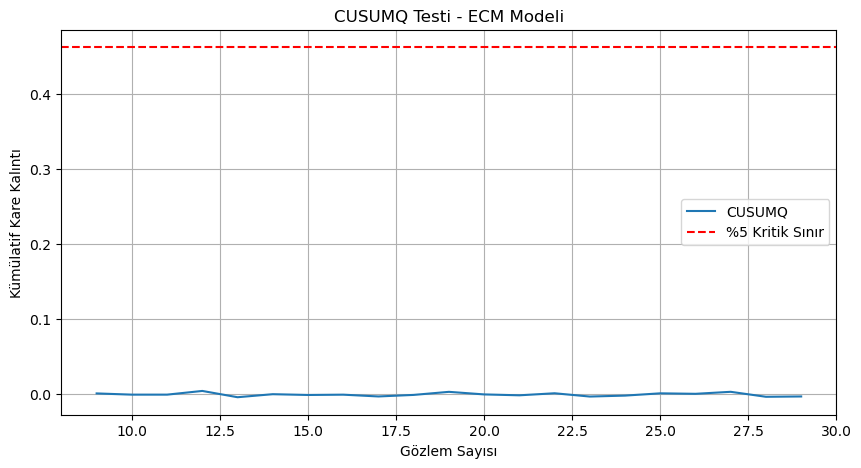

In [93]:
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.stats.diagnostic import recursive_olsresiduals
from statsmodels.api import OLS, add_constant

# ECM modelinde kullanılan veriler üzerinden yeniden tanımlama
Y = ecm_df['d_HDI']
X = add_constant(ecm_df[['d_GDP', 'd_EPL', 'ecm_resid_L1']])

# Gerekli fonksiyonu yeniden çalıştır, skip değerini artır
res = recursive_olsresiduals(OLS(Y, X).fit(), skip=10)

# CUSUM Grafiği
plt.figure(figsize=(10, 5))
plt.plot(res[3], label='CUSUM')
plt.axhline(0.948, color='red', linestyle='--', label='%5 Kritik Sınır')
plt.axhline(-0.948, color='red', linestyle='--')
plt.title("CUSUM Testi - ECM Modeli")
plt.xlabel("Gözlem Sayısı")
plt.ylabel("Kümülatif Kalıntı")
plt.legend()
plt.grid(True)
plt.show()

# CUSUMQ Grafiği
plt.figure(figsize=(10, 5))
plt.plot(res[4], label='CUSUMQ')
plt.axhline(0.462, color='red', linestyle='--', label='%5 Kritik Sınır')
plt.title("CUSUMQ Testi - ECM Modeli")
plt.xlabel("Gözlem Sayısı")
plt.ylabel("Kümülatif Kare Kalıntı")
plt.legend()
plt.grid(True)
plt.show()



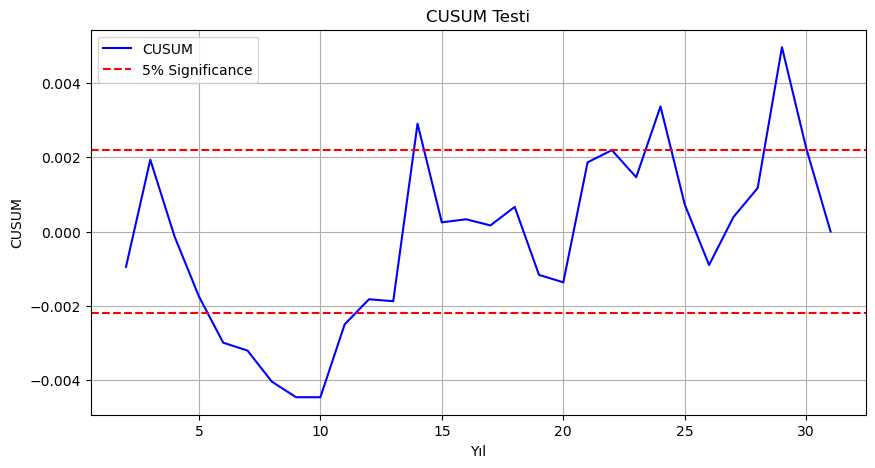

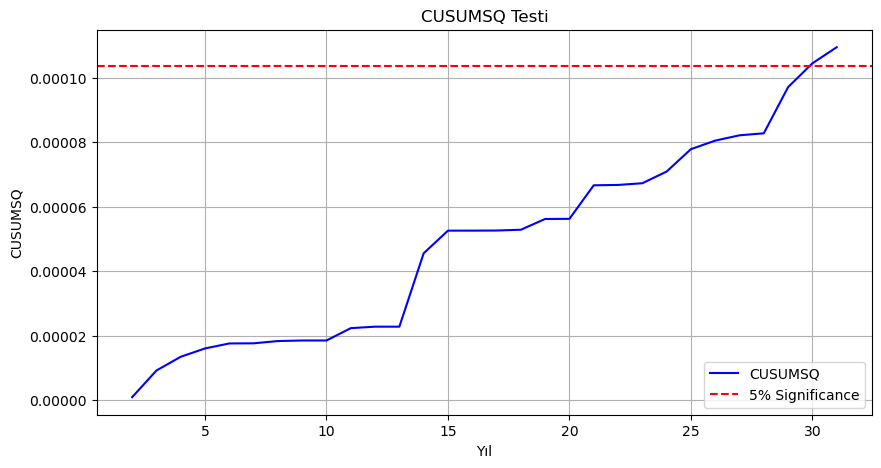

In [101]:
import matplotlib.pyplot as plt
import numpy as np

# CUSUM
cusum = np.cumsum(ecm_model.resid)
years = ecm_model.resid.index

plt.figure(figsize=(10,5))
plt.plot(years, cusum, label='CUSUM', color='blue')
plt.axhline(y=0.948 * np.std(cusum), color='red', linestyle='--', label='5% Significance')
plt.axhline(y=-0.948 * np.std(cusum), color='red', linestyle='--')
plt.title('CUSUM Testi')
plt.xlabel('Yıl')
plt.ylabel('CUSUM')
plt.legend()
plt.grid(True)
plt.show()

# CUSUMSQ
cusumsq = np.cumsum(ecm_model.resid ** 2)

plt.figure(figsize=(10,5))
plt.plot(years, cusumsq, label='CUSUMSQ', color='blue')
plt.axhline(y=0.948 * np.max(cusumsq), color='red', linestyle='--', label='5% Significance')

plt.title('CUSUMSQ Testi')
plt.xlabel('Yıl')
plt.ylabel('CUSUMSQ')
plt.legend()
plt.grid(True)
plt.show()


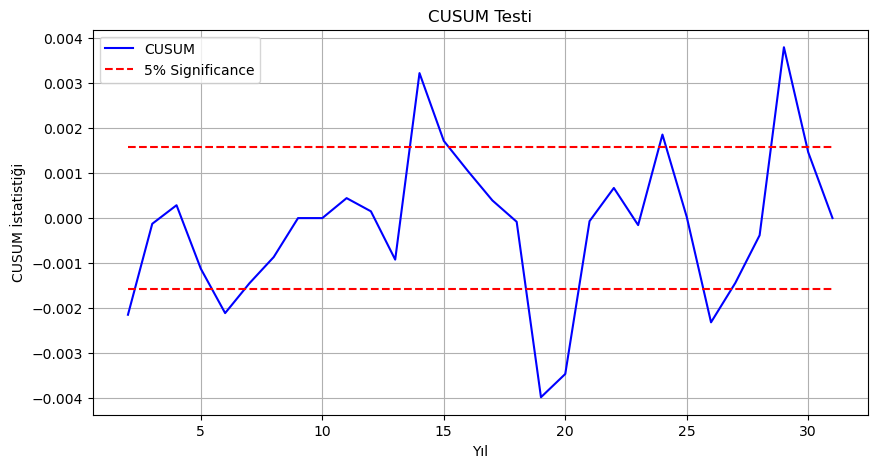

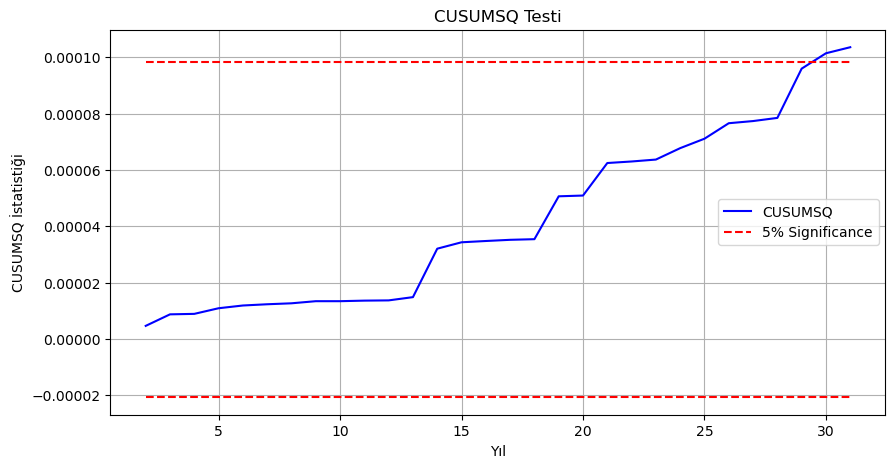

In [201]:
import matplotlib.pyplot as plt
import numpy as np
df = pd.read_excel('ger_data.xlsx', index_col=0)

cusum = np.cumsum(model.resid)
years = model.resid.index


# CUSUM Grafiği
plt.figure(figsize=(10,5))
plt.plot(years, cusum, label='CUSUM', color='blue')
plt.plot(years, 0.948 * np.std(cusum) * np.ones_like(cusum), 'r--', label='5% Significance')
plt.plot(years, -0.948 * np.std(cusum) * np.ones_like(cusum), 'r--')
plt.title('CUSUM Testi')
plt.xlabel('Yıl')
plt.ylabel('CUSUM İstatistiği') 
plt.legend()
plt.grid(True)
plt.show()

# CUSUMSQ Grafiği

cusumsq = np.cumsum(model.resid ** 2)
years = model.resid.index

plt.figure(figsize=(10,5))
plt.plot(years, cusumsq, label='CUSUMSQ', color='blue')
plt.plot(years, 0.948 * np.max(cusumsq) * np.ones_like(cusumsq), 'r--', label='5% Significance')
plt.plot(years, -0.2 * np.max(cusumsq) * np.ones_like(cusumsq), 'r--')
plt.title('CUSUMSQ Testi')
plt.xlabel('Yıl')
plt.ylabel('CUSUMSQ İstatistiği') 
plt.legend()
plt.grid(True)
plt.show()

In [109]:
#Ramsey RESET
import pandas as pd
import statsmodels.api as sm
from statsmodels.stats.diagnostic import linear_reset

# Veri setini yükle
df = pd.read_excel('ger_data.xlsx')  # Eğer başka bir yol kullanıyorsan onu güncelle

# Bağımlı ve bağımsız değişkenleri tanımla
Y = df['HDI']
X = sm.add_constant(df[['GDP', 'EPL']])

# Düzeyde OLS modeli kur
model = sm.OLS(Y, X).fit()

# Ramsey RESET testi (power=2, varsayılan ayar)
reset_test = linear_reset(model, power=2, use_f=True)

# Sonuçları yazdır
print("=== Ramsey RESET Testi ===")
print(f"F-istatistiği: {reset_test.fvalue:.4f}")
print(f"p-değeri: {reset_test.pvalue:.4f}")

if reset_test.pvalue > 0.05:
    print("Sonuç: H0 reddedilemedi → Model doğru spesifiye edilmiş.")
else:
    print("Sonuç: H0 reddedildi → Model yanlış spesifiye edilmiş olabilir.")


=== Ramsey RESET Testi ===
F-istatistiği: 2.1343
p-değeri: 0.1552
Sonuç: H0 reddedilemedi → Model doğru spesifiye edilmiş.


In [103]:
#RAMSEY RESET
import pandas as pd
import statsmodels.api as sm
from statsmodels.stats.diagnostic import linear_reset

# Veri setini yükle
df = pd.read_excel('ger_data.xlsx', index_col=0)

# Bağımlı ve bağımsız değişkenleri tanımla
y = df['HDI']
X = sm.add_constant(df[['REC', 'GDP', 'CO2', 'EPL']])  # Modelin bağımsız değişkenleri

# OLS modeli kur
model = sm.OLS(y, X).fit()

# Ramsey RESET testi (varsayılan olarak ikinci dereceden polinom ekler)
reset_result = linear_reset(model, power=2, use_f=True)

# Sonuçları yazdır
print("=== Ramsey RESET Testi ===")
print(f"F-istatistiği: {reset_result.fvalue:.4f}")
print(f"p-değeri: {reset_result.pvalue:.4f}")

if reset_result.pvalue > 0.05:
    print("Sonuç: H0 reddedilemedi → Model doğru spesifiye edilmiş.")
else:
    print("Sonuç: H0 reddedildi → Model yanlış spesifiye edilmiş olabilir.")

=== Ramsey RESET Testi ===
F-istatistiği: 55.5434
p-değeri: 0.0000
Sonuç: H0 reddedildi → Model yanlış spesifiye edilmiş olabilir.


In [203]:
import statsmodels.api as sm
from statsmodels.tsa.ardl import ARDL

y = df['HDI']
X = df[['GDP', 'EPL']]

ardl_model = ARDL(endog=y, exog=X, lags=1).fit()

print(ardl_model.summary())


                              ARDL Model Results                              
Dep. Variable:                    HDI   No. Observations:                   32
Model:                  ARDL(1, 0, 0)   Log Likelihood                 151.806
Method:               Conditional MLE   S.D. of innovations              0.002
Date:                Sat, 03 May 2025   AIC                           -293.612
Time:                        05:46:28   BIC                           -286.442
Sample:                             1   HQIC                          -291.274
                                   32                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0777      0.016      4.771      0.000       0.044       0.111
HDI.L1         0.9156      0.019     48.213      0.000       0.877       0.955
GDP.L0         0.0003      0.000      2.062      0.0

C:\Users\nisak\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)


In [205]:
# Uzun dönem katsayıları
long_run_coefs = {}

phi = 1 - ardl_model.params['HDI.L1'] 

for var in ['GDP.L0', 'EPL.L0']:
    long_run_coefs[var] = ardl_model.params[var] / phi

for var, coef in long_run_coefs.items():
    print(f"Uzun Dönem Katsayısı ({var}): {coef:.6f}")


Uzun Dönem Katsayısı (GDP.L0): 0.004043
Uzun Dönem Katsayısı (EPL.L0): 0.033364


In [207]:
# Error Correction Term (ECM) Katsayısı
ecm_term = 1 - ardl_model.params['HDI.L1']

print(f"Error Correction Term (ECM katsayısı): {ecm_term:.4f}")


Error Correction Term (ECM katsayısı): 0.0844


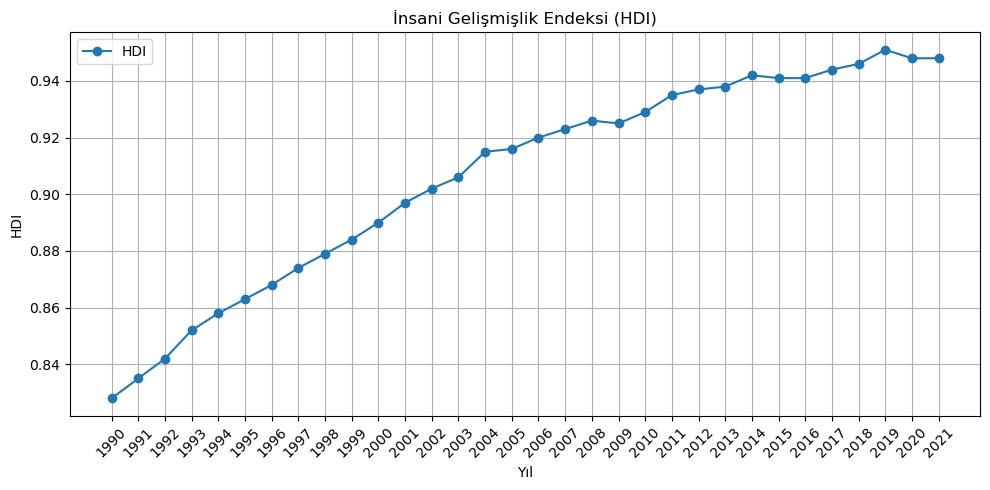

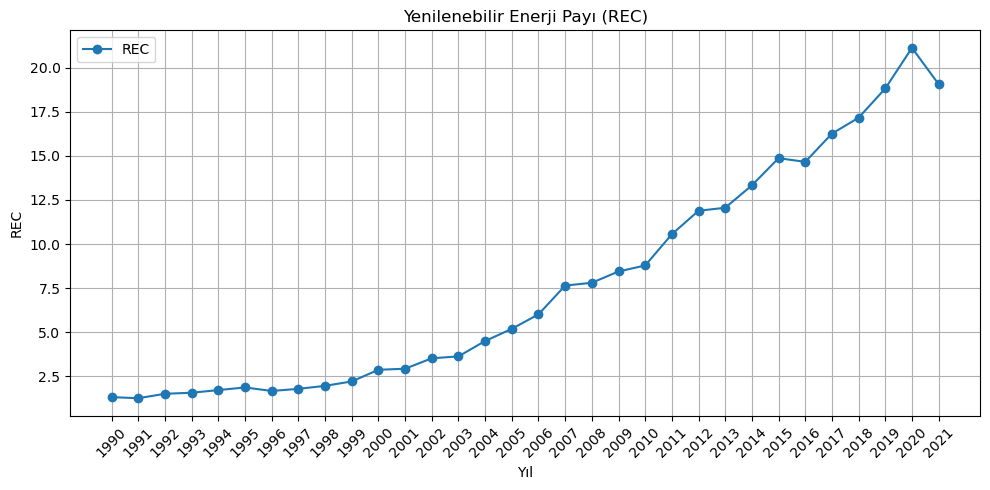

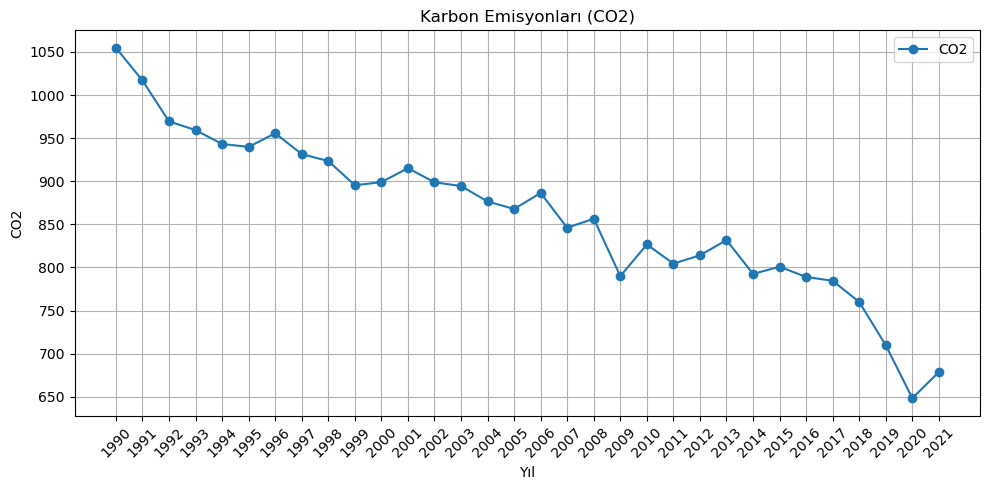

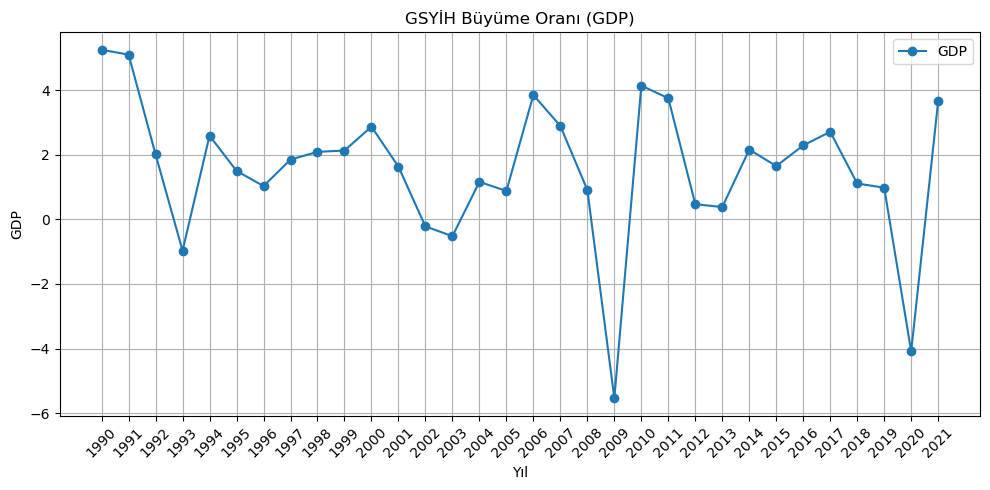

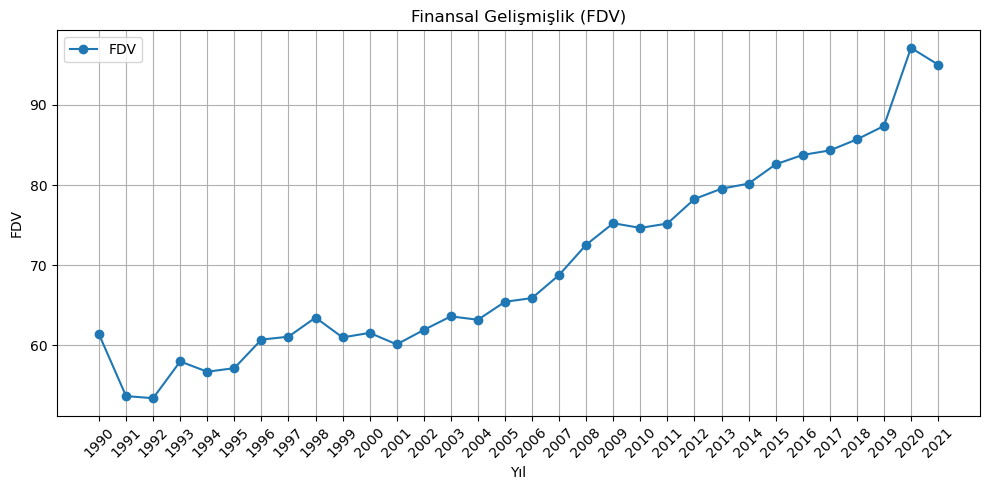

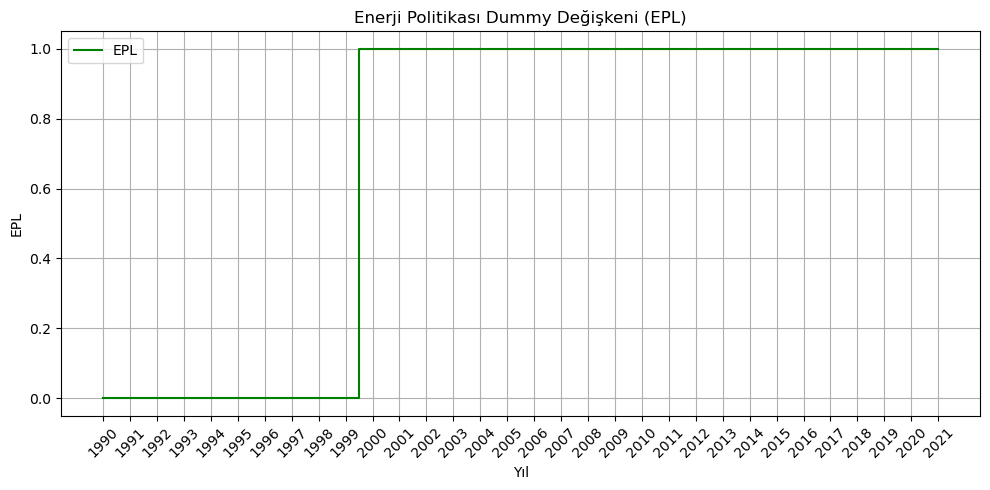

In [209]:
years = list(range(1990, 2022))
import matplotlib.pyplot as plt

years = list(range(1990, 2022))

variables = ['HDI', 'REC', 'CO2', 'GDP', 'FDV', 'EPL']
titles = ['İnsani Gelişmişlik Endeksi (HDI)',
          'Yenilenebilir Enerji Payı (REC)',
          'Karbon Emisyonları (CO2)',
          'GSYİH Büyüme Oranı (GDP)',
          'Finansal Gelişmişlik (FDV)',
          'Enerji Politikası Dummy Değişkeni (EPL)']

for var, title in zip(variables, titles):
    plt.figure(figsize=(10,5))
    
    if var == 'EPL':
        plt.step(years, df[var], where='mid', label=var, color='green')
    else:
        plt.plot(years, df[var], marker='o', label=var)
    
    plt.title(title)
    plt.xlabel('Yıl') 
    plt.ylabel(var)  
    plt.xticks(years, rotation=45) 
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()


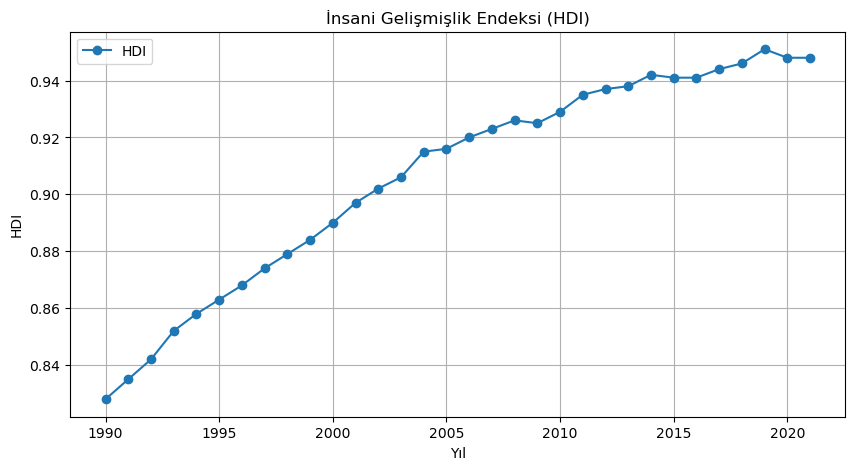

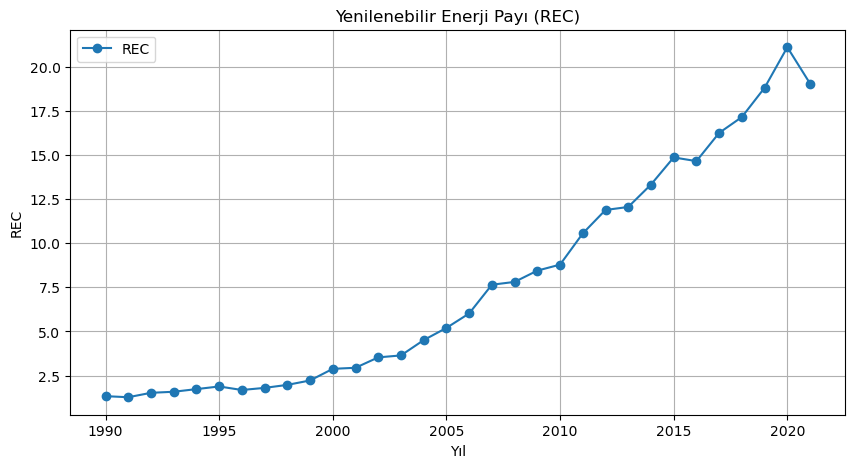

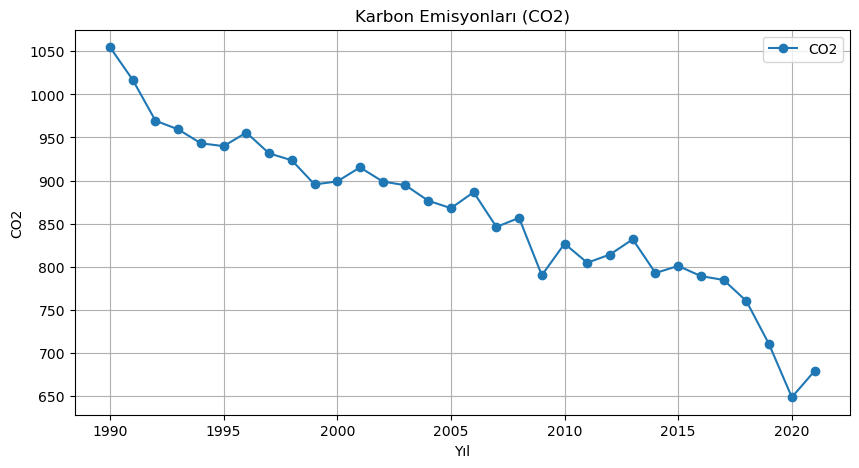

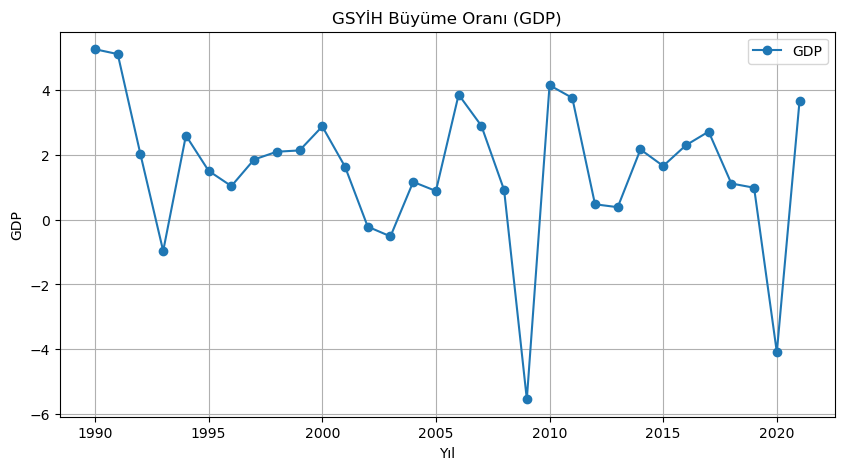

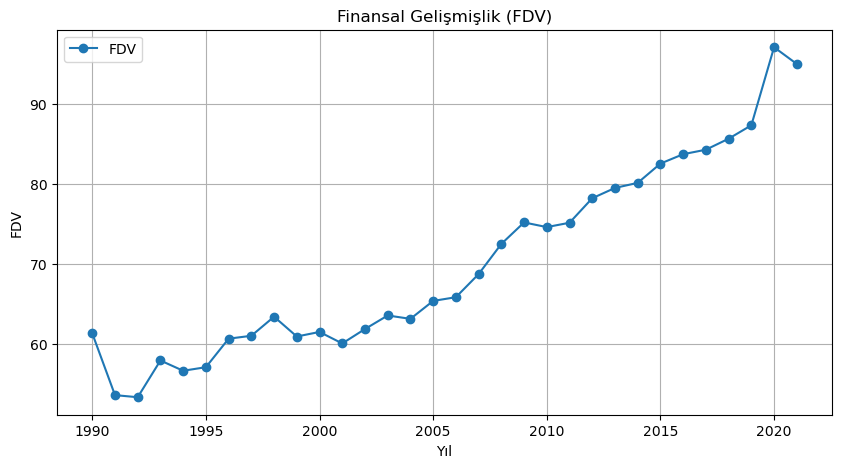

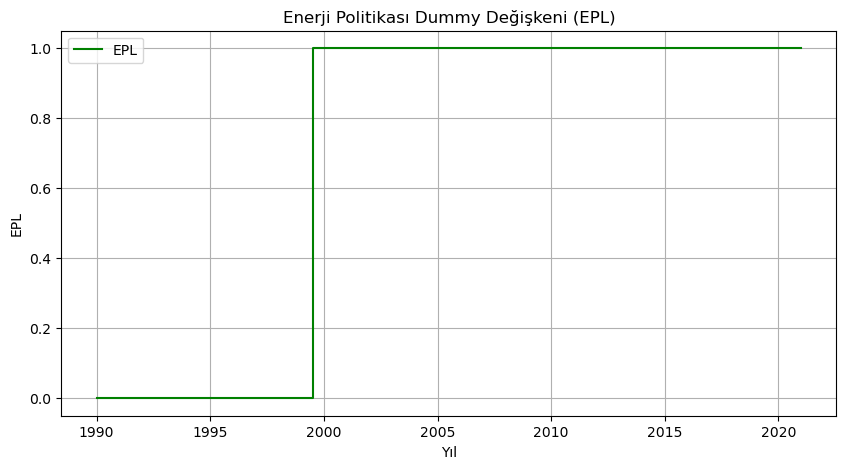

In [211]:
import matplotlib.pyplot as plt

variables = ['HDI', 'REC', 'CO2', 'GDP', 'FDV', 'EPL']
titles = ['İnsani Gelişmişlik Endeksi (HDI)',
          'Yenilenebilir Enerji Payı (REC)',
          'Karbon Emisyonları (CO2)',
          'GSYİH Büyüme Oranı (GDP)',
          'Finansal Gelişmişlik (FDV)',
          'Enerji Politikası Dummy Değişkeni (EPL)']

for var, title in zip(variables, titles):
    plt.figure(figsize=(10,5))
    if var == 'EPL':
        plt.step(df.index, df[var], where='mid', label=var, color='green')
    else:
        plt.plot(df.index, df[var], marker='o', label=var)
    plt.title(title)
    plt.xlabel('Yıl')
    plt.ylabel(var)
    plt.grid(True)
    plt.legend()
    plt.show()


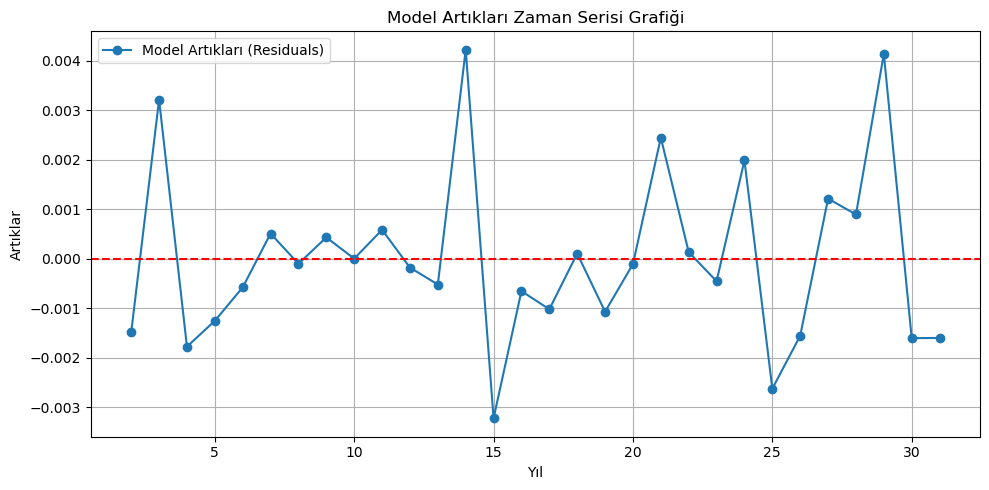

In [213]:
import matplotlib.pyplot as plt

residuals = ecm_model.resid

plt.figure(figsize=(10,5))
plt.plot(residuals, marker='o', linestyle='-', label='Model Artıkları (Residuals)')
plt.title('Model Artıkları Zaman Serisi Grafiği')
plt.xlabel('Yıl')
plt.ylabel('Artıklar')
plt.axhline(y=0, color='r', linestyle='--')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


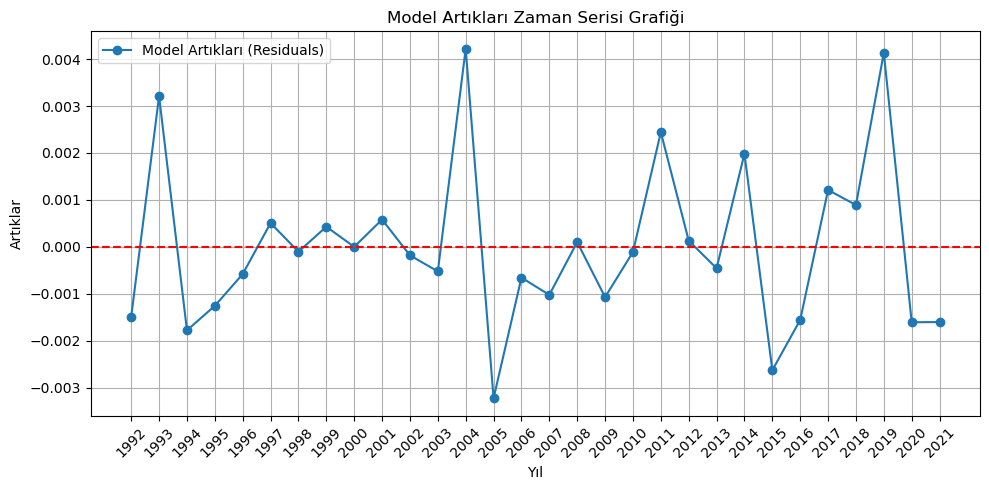

In [215]:
import matplotlib.pyplot as plt

years_for_resid = list(range(1992, 2022))

plt.figure(figsize=(10,5))
plt.plot(years_for_resid, residuals, marker='o', linestyle='-', label='Model Artıkları (Residuals)')
plt.title('Model Artıkları Zaman Serisi Grafiği')
plt.xlabel('Yıl')  # X ekseni: Yıl
plt.ylabel('Artıklar')  # Y ekseni: Artıklar
plt.axhline(y=0, color='r', linestyle='--')
plt.xticks(years_for_resid, rotation=45)
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()



<Figure size 1000x500 with 0 Axes>

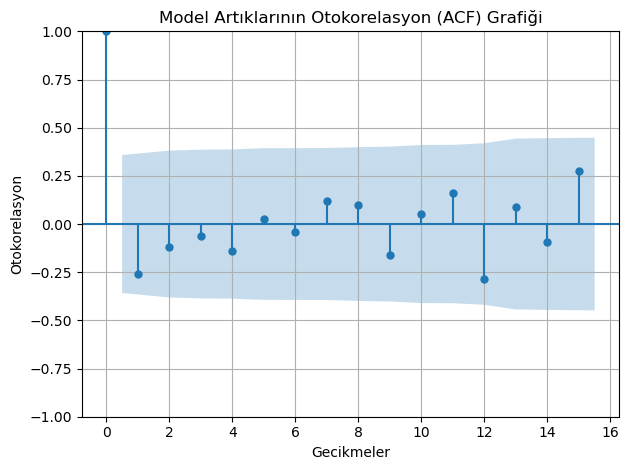

In [217]:
from statsmodels.graphics.tsaplots import plot_acf
import matplotlib.pyplot as plt

# ACF Grafiği
plt.figure(figsize=(10,5))
plot_acf(residuals, lags=15, alpha=0.05)  # İlk 15 gecikmeye bakalım
plt.title('Model Artıklarının Otokorelasyon (ACF) Grafiği')
plt.xlabel('Gecikmeler')
plt.ylabel('Otokorelasyon')
plt.grid(True)
plt.tight_layout()
plt.show()


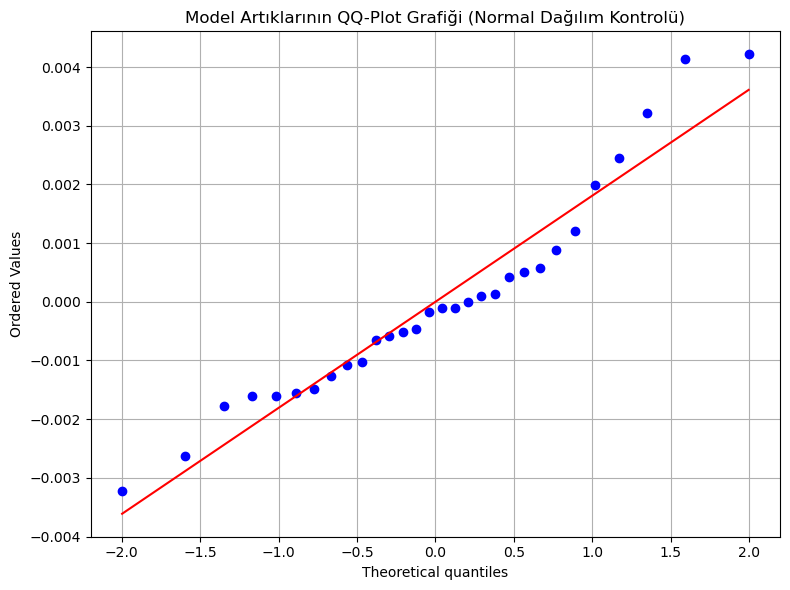

In [219]:
import scipy.stats as stats
import matplotlib.pyplot as plt

# QQ-Plot
plt.figure(figsize=(8,6))
stats.probplot(residuals, dist="norm", plot=plt)
plt.title('Model Artıklarının QQ-Plot Grafiği (Normal Dağılım Kontrolü)')
plt.grid(True)
plt.tight_layout()
plt.show()


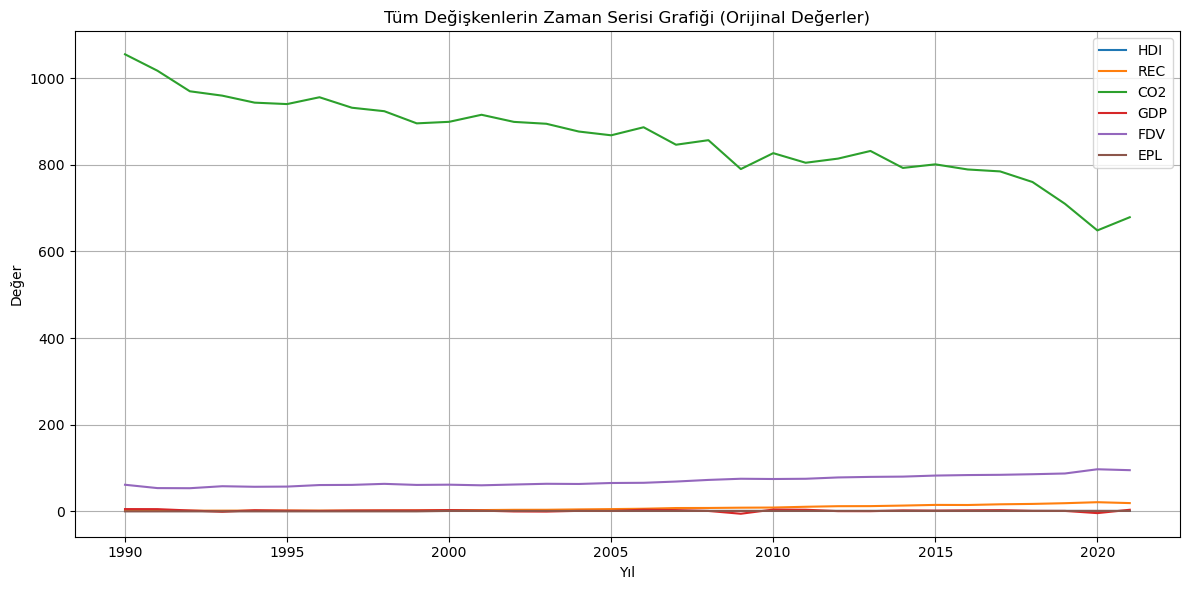

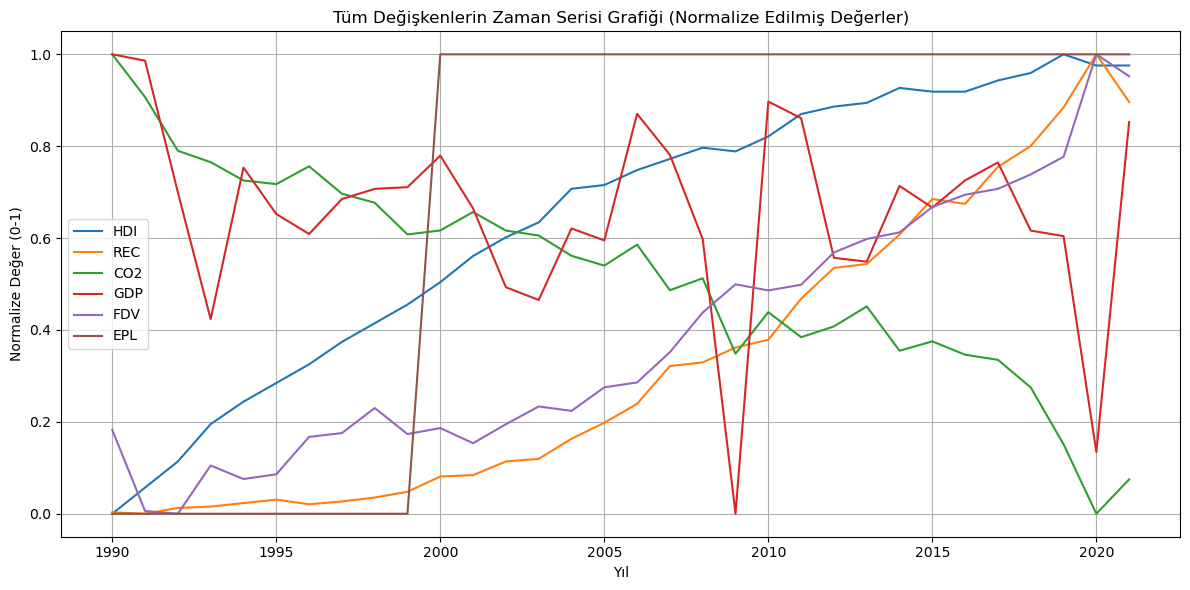

In [221]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler

df = pd.read_excel("ger_data.xlsx", index_col=0)
df.index = pd.to_datetime(df.index, format='%Y')  # Yıl formatı

plt.figure(figsize=(12, 6))
for var in ['HDI', 'REC', 'CO2', 'GDP', 'FDV', 'EPL']:
    plt.plot(df.index.year, df[var], label=var)

plt.title('Tüm Değişkenlerin Zaman Serisi Grafiği (Orijinal Değerler)')
plt.xlabel('Yıl')
plt.ylabel('Değer')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
df_normalized = pd.DataFrame(
    scaler.fit_transform(df[['HDI', 'REC', 'CO2', 'GDP', 'FDV', 'EPL']]),
    index=df.index,
    columns=['HDI', 'REC', 'CO2', 'GDP', 'FDV', 'EPL']
)

plt.figure(figsize=(12, 6))
for var in ['HDI', 'REC', 'CO2', 'GDP', 'FDV', 'EPL']:
    plt.plot(df_normalized.index.year, df_normalized[var], label=var)

plt.title('Tüm Değişkenlerin Zaman Serisi Grafiği (Normalize Edilmiş Değerler)')
plt.xlabel('Yıl')
plt.ylabel('Normalize Değer (0-1)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()
